# Resume–Job Skill Gap Analysis

Use this notebook for exploratory analysis, statistical tests, visualizations, and interpretation. Keep reusable logic in `src/`.

In [43]:
import sys
sys.path.append('../src')
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from extract_skills import get_skill_pattern, extract_skills

In [44]:
sns.set()

## 1. Data validation

Record raw counts, missing values, duplicate counts, and cleaning decisions before modelling.

In [45]:
# Define raw file paths
raw_jobs_file = '../data/raw/jobs.csv'
raw_courses_file = '../data/raw/courses.csv'
raw_resumes_file = '../data/raw/resumes.csv'

In [46]:
# Define cleaned file paths
cleaned_jobs_file = '../data/processed/jobs_clean.csv'
cleaned_courses_file = '../data/processed/courses_clean.csv'
cleaned_resumes_file = '../data/processed/resumes_clean.csv'

In [47]:
# Read raw CSV files
raw_jobs = pd.read_csv(raw_jobs_file)
raw_courses = pd.read_csv(raw_courses_file)
raw_resumes = pd.read_csv(raw_resumes_file)

In [48]:
# Read cleaned CSV files
cleaned_jobs = pd.read_csv(cleaned_jobs_file)
cleaned_courses = pd.read_csv(cleaned_courses_file)
cleaned_resumes = pd.read_csv(cleaned_resumes_file)

In [49]:
# Print raw dataset sizes
print('Raw Jobs:', raw_jobs.shape)
print('Raw Courses:', raw_courses.shape)
print('Raw Resumes:', raw_resumes.shape)

Raw Jobs: (100, 9)
Raw Courses: (166, 3)
Raw Resumes: (2484, 4)


In [50]:
# Print cleaned dataset sizes
print('Cleaned Jobs:', cleaned_jobs.shape)
print('Cleaned Courses:', cleaned_courses.shape)
print('Cleaned Resumes:', cleaned_resumes.shape)

Cleaned Jobs: (93, 10)
Cleaned Courses: (93, 5)
Cleaned Resumes: (100, 6)


In [51]:
skill_patterns = get_skill_pattern()

## 2. Exploratory data analysis

Answer the research questions. Do not create decorative charts.

### JOB EDA
---

In [52]:
# Count jobs in each category
jobs_per_category = cleaned_jobs['category'].value_counts().sort_index()
print(jobs_per_category)

category
Computer and IT            24
Data and Analytics         24
Science and Engineering    24
Software Engineering       21
Name: count, dtype: int64


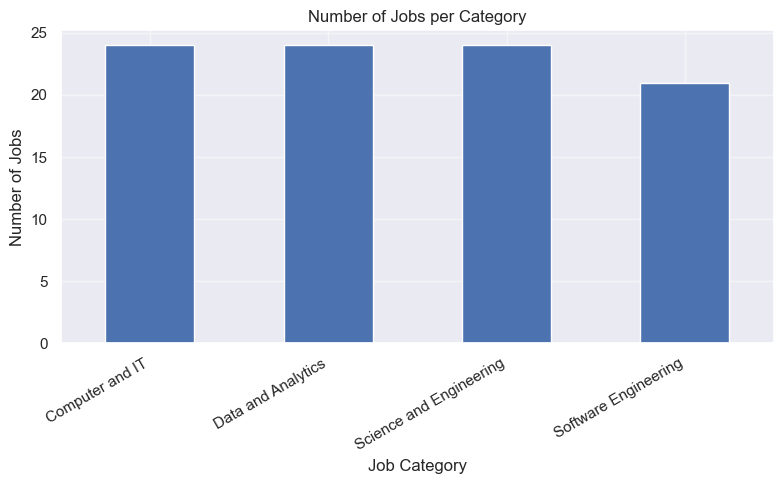

In [53]:
# Plot jobs per category
plt.figure(figsize=(8, 5))
jobs_per_category.plot(kind='bar')
plt.title('Number of Jobs per Category')
plt.xlabel('Job Category')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [54]:
# Count unique companies in each job category
companies_per_category = cleaned_jobs.groupby('category')['company'].nunique().sort_values(ascending=False)
print(companies_per_category)

category
Computer and IT            16
Data and Analytics         14
Science and Engineering    14
Software Engineering       10
Name: company, dtype: int64


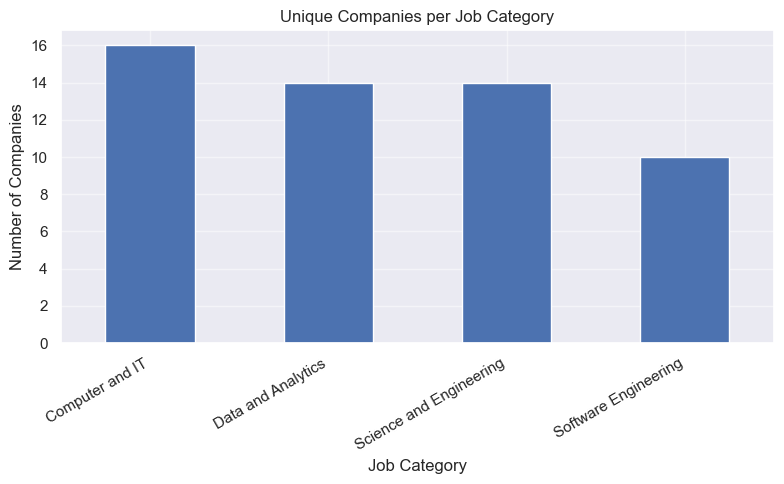

In [55]:
# Plot unique companies per category
plt.figure(figsize=(8, 5))
companies_per_category.plot(kind='bar')
plt.title('Unique Companies per Job Category')
plt.xlabel('Job Category')
plt.ylabel('Number of Companies')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [56]:
# Count jobs at each experience level
job_levels = cleaned_jobs['job_level'].value_counts()
print(job_levels)

job_level
Senior Level    46
Mid Level       40
Entry Level      5
Internship       2
Name: count, dtype: int64


In [57]:
# Compare job levels between categories
job_level_category = pd.crosstab(cleaned_jobs['category'], cleaned_jobs['job_level'])
print(job_level_category)

job_level                Entry Level  Internship  Mid Level  Senior Level
category                                                                 
Computer and IT                    0           0         15             9
Data and Analytics                 0           1         10            13
Science and Engineering            0           0          8            16
Software Engineering               5           1          7             8


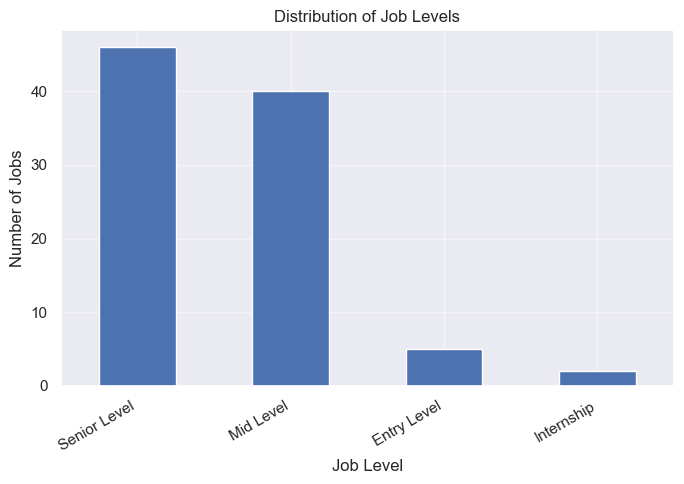

In [58]:
# Plot job levels
plt.figure(figsize=(7, 5))
job_levels.plot(kind='bar')
plt.title('Distribution of Job Levels')
plt.xlabel('Job Level')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [59]:
# Create word and two-word term counts
job_vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2), min_df=3)
job_term_matrix = job_vectorizer.fit_transform(cleaned_jobs['cleaned_description'])

# Get term names and total frequencies
job_terms = job_vectorizer.get_feature_names_out()
job_term_counts = pd.Series(np.asarray(job_term_matrix.sum(axis=0)).ravel(), index=job_terms).sort_values(ascending=False)

# Show the most frequent terms
print(job_term_counts.head(30))

experience        457
business          324
data              319
work              308
benefits          305
team              260
engineering       235
including         229
job               224
qualifications    221
technical         195
information       191
related           182
skills            180
management        169
company           169
solutions         168
position          167
design            166
support           162
role              158
ability           158
process           151
time              151
requirements      148
development       147
customer          146
performance       145
teams             141
paid              140
dtype: int64


In [60]:
# Extract technical skills from each job
job_skills = []

for job_description in cleaned_jobs['cleaned_description']:
    current_skills = extract_skills(job_description, skill_patterns)
    job_skills.append(current_skills)

# Store technical skills for each job
cleaned_jobs['tech_skills'] = job_skills

# Put each technical skill into its own row
job_skills_exploded = cleaned_jobs['tech_skills'].explode()

# Count how many jobs mention each skill
job_skill_counts = job_skills_exploded.value_counts()

# Show most common technical skills
print(job_skill_counts.head(20))

tech_skills
agile               20
python              13
sql                 12
azure               11
machine learning    10
java                10
cybersecurity        9
aws                  9
ci/cd                7
data science         7
gcp                  7
rest                 6
javascript           6
jira                 5
windows              5
power bi             5
data analysis        5
c++                  4
tensorflow           4
typescript           4
Name: count, dtype: int64


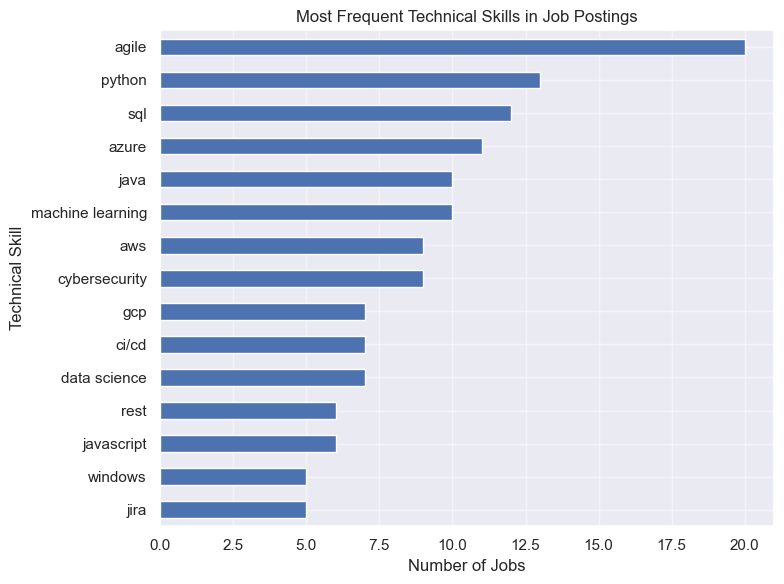

In [61]:
# Plot the 15 most common job skills
top_job_skills = job_skill_counts.head(15)

plt.figure(figsize=(8, 6))
top_job_skills.sort_values().plot(kind='barh')
plt.title('Most Frequent Technical Skills in Job Postings')
plt.xlabel('Number of Jobs')
plt.ylabel('Technical Skill')
plt.tight_layout()
plt.show()

In [62]:
# Create technical skill presence matrix for jobs
job_skill_matrix = pd.crosstab(job_skills_exploded.index, job_skills_exploded)

# Convert counts to binary presence
job_skill_matrix = (job_skill_matrix > 0).astype(int)

# Add back jobs with no detected technical skills
job_skill_matrix = job_skill_matrix.reindex(cleaned_jobs.index, fill_value=0)

In [63]:
# Add job category to the skill table
job_skill_category = job_skill_matrix.copy()
job_skill_category['category'] = cleaned_jobs['category'].values

# Select the most common skills
top_skill_names = job_skill_counts.head(12).index.tolist()

# Calculate percentage of jobs mentioning each skill
category_skill_rate = job_skill_category.groupby('category')[top_skill_names].mean() * 100

print(category_skill_rate.round(1))

tech_skills              agile  python   sql  azure  machine learning  java  \
category                                                                      
Computer and IT           16.7    16.7  12.5    8.3              12.5   4.2   
Data and Analytics        33.3    20.8  25.0   16.7              16.7  16.7   
Science and Engineering    8.3     4.2   4.2    8.3               8.3   0.0   
Software Engineering      28.6    14.3   9.5   14.3               4.8  23.8   

tech_skills              cybersecurity   aws  ci/cd  data science   gcp  rest  
category                                                                       
Computer and IT                   16.7  12.5    4.2           8.3   4.2   4.2  
Data and Analytics                 4.2   8.3    4.2          12.5   8.3   4.2  
Science and Engineering            4.2   4.2    4.2           0.0   4.2   4.2  
Software Engineering              14.3  14.3   19.0           9.5  14.3  14.3  


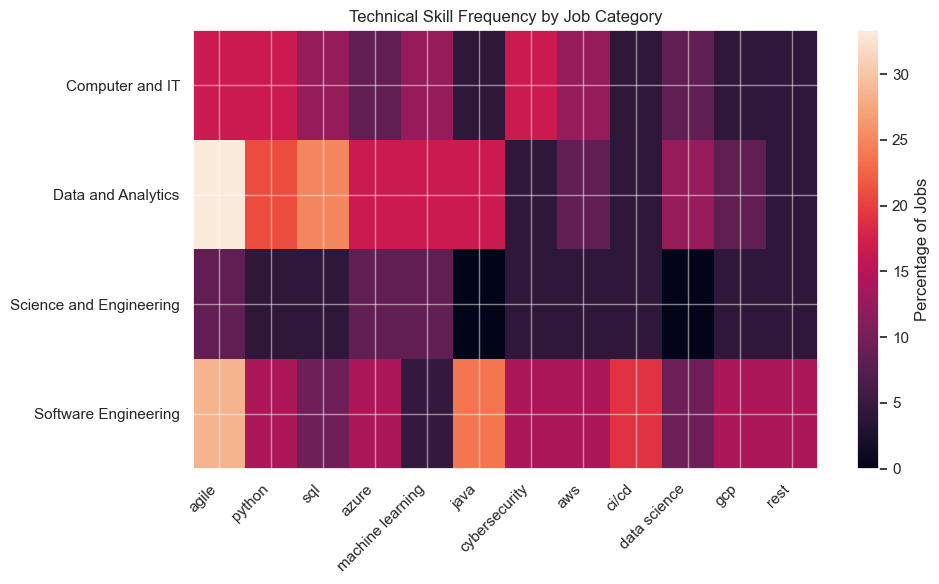

In [64]:
# Plot technical skill differences among categories
plt.figure(figsize=(10, 6))
plt.imshow(category_skill_rate, aspect='auto')
plt.xticks(range(len(top_skill_names)), top_skill_names, rotation=45, ha='right')
plt.yticks(range(len(category_skill_rate.index)), category_skill_rate.index)
plt.colorbar(label='Percentage of Jobs')
plt.title('Technical Skill Frequency by Job Category')
plt.tight_layout()
plt.show()

### RESUME EDA
---

In [65]:
# Show technical skill count statistics
print(cleaned_resumes['num_tech_skills'].describe())

count    100.000000
mean       6.510000
std        4.611131
min        1.000000
25%        3.000000
50%        6.000000
75%        9.000000
max       24.000000
Name: num_tech_skills, dtype: float64


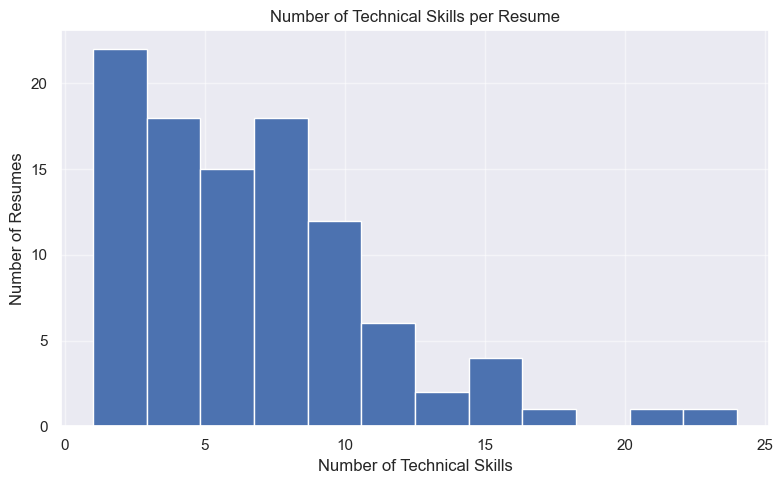

In [66]:
# Plot technical skill counts
plt.figure(figsize=(8, 5))
plt.hist(cleaned_resumes['num_tech_skills'], bins=12)
plt.title('Number of Technical Skills per Resume')
plt.xlabel('Number of Technical Skills')
plt.ylabel('Number of Resumes')
plt.tight_layout()
plt.show()

In [67]:
# Convert stored skill strings back to sets
cleaned_resumes['tech_skills_list'] = cleaned_resumes['tech_skills'].apply(ast.literal_eval)

# Put every skill into its own row
resume_skills = cleaned_resumes['tech_skills_list'].explode()

# Count the most common resume skills
resume_skill_counts = resume_skills.value_counts()

print(resume_skill_counts.head(20))

tech_skills_list
windows                 68
active directory        44
sql                     40
cisco                   39
linux                   30
lan                     27
sharepoint              25
oracle                  24
wan                     23
vmware                  22
html                    19
network security        19
information security    18
unix                    18
tcp/ip                  17
firewall                16
sql server              15
data analysis           13
java                    11
css                     10
Name: count, dtype: int64


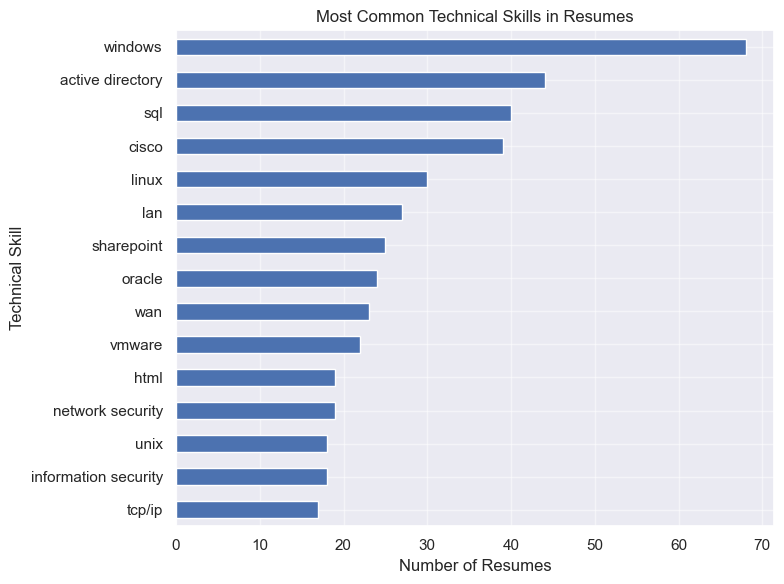

In [68]:
# Plot the 15 most common resume skills
top_resume_skills = resume_skill_counts.head(15)

plt.figure(figsize=(8, 6))
top_resume_skills.sort_values().plot(kind='barh')
plt.title('Most Common Technical Skills in Resumes')
plt.xlabel('Number of Resumes')
plt.ylabel('Technical Skill')
plt.tight_layout()
plt.show()

### COURSE EDA
---

In [69]:
# Remove prerequisite text for concept-frequency analysis
cleaned_courses['eda_description'] = (cleaned_courses['cleaned_description'].str.replace(r'(?i)\bprerequisite:.*$', ' ',regex=True))

# Define course-specific uninformative words
course_stop_words = [
    'course',
    'courses',
    'student',
    'students',
    'credit',
    'credits',
    'cmpt',
    'prerequisite'
]

# Create term counts
course_vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 2), min_df=2)
course_term_matrix = course_vectorizer.fit_transform(cleaned_courses['eda_description'])

# Get term frequencies
course_terms = course_vectorizer.get_feature_names_out()

course_term_counts = pd.Series(np.asarray(course_term_matrix.sum(axis=0)).ravel(), index=course_terms).sort_values(ascending=False)

# Remove common administrative terms
course_term_counts = course_term_counts[~course_term_counts.index.isin(course_stop_words)]

print(course_term_counts.head(30))

data                 64
systems              63
topics               53
computer             35
programming          35
computing            34
design               31
include              31
algorithms           30
topics include       27
software             26
techniques           25
learning             22
science              21
concepts             19
analysis             19
advanced             19
introduction         17
computing science    16
models               16
including            16
network              16
security             16
information          15
fundamental          15
covers               15
research             14
web                  14
applications         14
experience           13
dtype: int64


In [70]:
# Extract technical skills from each course
course_skills = []

for course_description in cleaned_courses['cleaned_description']:
    current_skills = extract_skills(course_description, skill_patterns)
    course_skills.append(current_skills)

# Store technical skills for each course
cleaned_courses['tech_skills'] = course_skills

# Put each technical skill into its own row
course_skills_exploded = cleaned_courses['tech_skills'].explode()

# Count how many courses mention each skill
course_skill_counts = course_skills_exploded.value_counts()

# Show most common technical skills
print(course_skill_counts.head(20))

tech_skills
machine learning    8
data analysis       3
cybersecurity       3
c++                 2
network security    2
deep learning       2
tcp/ip              2
python              1
unix                1
java                1
javascript          1
html                1
typescript          1
rest                1
css                 1
spring              1
switching           1
data science        1
Name: count, dtype: int64


In [71]:
# Create job and course skill comparison
market_skill_summary = pd.DataFrame(
    {
        'job_count': job_skill_counts,
        'course_count': course_skill_counts
    }
)

# Keep skills that appear in the job market
market_skill_summary = market_skill_summary[market_skill_summary['job_count'] > 0]

# Sort by job-market frequency
market_skill_summary = market_skill_summary.sort_values(by='job_count', ascending=False)

print(market_skill_summary.head(30))

                  job_count  course_count
tech_skills                              
agile                  20.0           NaN
python                 13.0           1.0
sql                    12.0           NaN
azure                  11.0           NaN
java                   10.0           1.0
machine learning       10.0           8.0
cybersecurity           9.0           3.0
aws                     9.0           NaN
data science            7.0           1.0
gcp                     7.0           NaN
ci/cd                   7.0           NaN
javascript              6.0           1.0
rest                    6.0           1.0
data analysis           5.0           3.0
windows                 5.0           NaN
power bi                5.0           NaN
jira                    5.0           NaN
spark                   4.0           NaN
c++                     4.0           2.0
typescript              4.0           1.0
scrum                   4.0           NaN
tensorflow              4.0       

In [72]:
# Find market skills never mentioned in course descriptions
skills_not_in_courses = market_skill_summary[market_skill_summary['course_count'] == 0]

print('Market skills not mentioned in courses:')
print(skills_not_in_courses)

Market skills not mentioned in courses:
Empty DataFrame
Columns: [job_count, course_count]
Index: []


In [73]:
# Find market skills appearing in only one course
rare_course_skills = market_skill_summary[market_skill_summary['course_count'] == 1]

print('Market skills mentioned in only one course:')
print(rare_course_skills)

Market skills mentioned in only one course:
              job_count  course_count
tech_skills                          
python             13.0           1.0
java               10.0           1.0
data science        7.0           1.0
javascript          6.0           1.0
rest                6.0           1.0
typescript          4.0           1.0
spring              3.0           1.0
css                 1.0           1.0
html                1.0           1.0


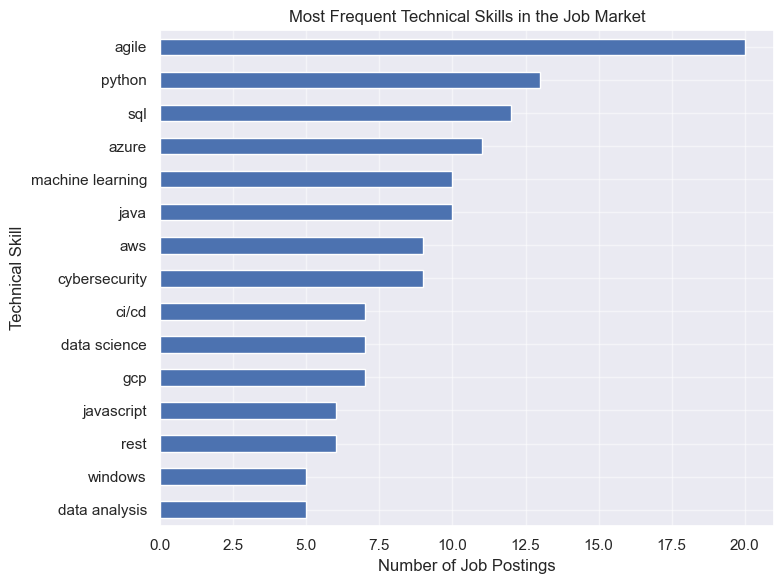

In [74]:
# Select the most frequent market skills
top_market_skills = market_skill_summary.head(15).copy()

# Plot job frequency
plt.figure(figsize=(8, 6))
top_market_skills['job_count'].sort_values().plot(kind='barh')
plt.title('Most Frequent Technical Skills in the Job Market')
plt.xlabel('Number of Job Postings')
plt.ylabel('Technical Skill')
plt.tight_layout()
plt.show()

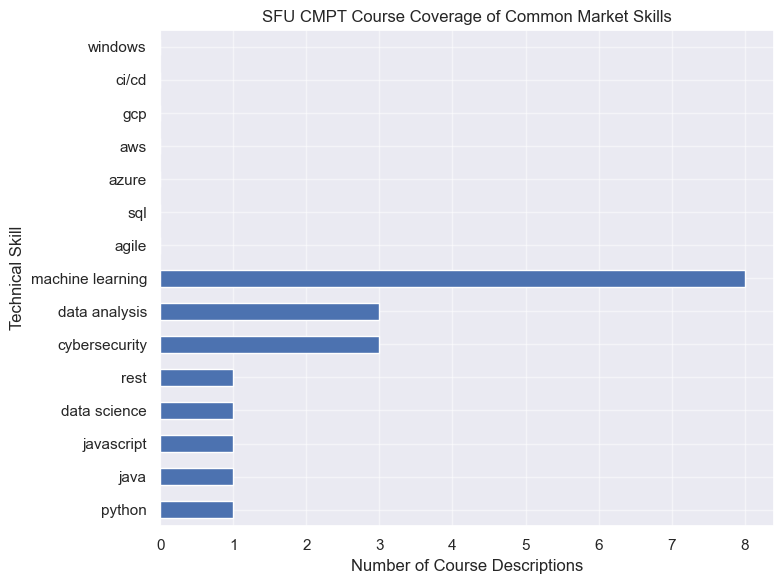

In [75]:
# Plot course coverage for the same market skills
plt.figure(figsize=(8, 6))
top_market_skills['course_count'].sort_values().plot(kind='barh')
plt.title('SFU CMPT Course Coverage of Common Market Skills')
plt.xlabel('Number of Course Descriptions')
plt.ylabel('Technical Skill')
plt.tight_layout()
plt.show()

## 3. Model evaluation

Compare the keyword baseline against TF-IDF on held-out labels.

## 4. Statistical analysis

Inspect assumptions before selecting ANOVA, Welch's ANOVA, or Kruskal–Wallis.

## 5. Findings and limitations

State what the data supports and what it does not support.